In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel

c:\Users\esabe\AppData\Local\r-miniconda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import sys, cmdstanpy
from cmdstanpy import cmdstan_path

print(sys.executable)
print(cmdstanpy.__version__)
print(cmdstan_path())

c:\Users\esabe\AppData\Local\r-miniconda\python.exe
1.3.0
C:\Users\esabe\AppData\Local\r-miniconda\Library\bin\cmdstan


In [7]:
old_old = 8  
old_new = 2   
new_old = 2   
new_new = 8   

N_old = old_old + old_new
N_new = new_old + new_new

data = {
    "N_old": N_old,
    "N_new": N_new,
    "y_old": [old_old, old_new],
    "y_new": [new_old, new_new]
}

print(data)

{'N_old': 10, 'N_new': 10, 'y_old': [8, 2], 'y_new': [2, 8]}


In [4]:
from cmdstanpy import CmdStanModel

model_1ht = CmdStanModel(stan_file="mpt_1ht.stan")
model_2ht = CmdStanModel(stan_file="mpt_2ht.stan")

18:29:37 - cmdstanpy - INFO - compiling stan file C:\Users\esabe\Documents\CSCI-4150\Cognitive-Modeling-HW4\mpt_1ht.stan to exe file C:\Users\esabe\Documents\CSCI-4150\Cognitive-Modeling-HW4\mpt_1ht.exe
18:31:41 - cmdstanpy - INFO - compiled model executable: C:\Users\esabe\Documents\CSCI-4150\Cognitive-Modeling-HW4\mpt_1ht.exe
18:31:41 - cmdstanpy - INFO - compiling stan file C:\Users\esabe\Documents\CSCI-4150\Cognitive-Modeling-HW4\mpt_2ht.stan to exe file C:\Users\esabe\Documents\CSCI-4150\Cognitive-Modeling-HW4\mpt_2ht.exe
18:32:08 - cmdstanpy - INFO - compiled model executable: C:\Users\esabe\Documents\CSCI-4150\Cognitive-Modeling-HW4\mpt_2ht.exe


In [8]:
fit_1ht = model_1ht.sample(
    data=data,
    chains=4,
    iter_sampling=2000,
    iter_warmup=1000,
    seed=123
)

fit_2ht = model_2ht.sample(
    data=data,
    chains=4,
    iter_sampling=2000,
    iter_warmup=1000,
    seed=123
)

18:34:37 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]



chain 1:  33%|███▎      | 1000/3000 [00:00<00:00, 9984.92it/s, (Sampling)]

chain 1:  33%|███▎      | 1001/3000 [00:00<00:00, 9662.56it/s, (Sampling)]


chain 2: 100%|██████████| 3000/3000 [00:00<00:00, 13121.93it/s, (Sampling completed)]

chain 3: 100%|██████████| 3000/3000 [00:00<00:00, 13124.44it/s, (Sampling completed)]




chain 4: 100%|██████████| 3000/3000 [00:00<00:00, 12965.35it/s, (Sampling completed)]


18:34:37 - cmdstanpy - INFO - CmdStan done processing.


18:34:38 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]





chain 1:  53%|█████▎    | 1600/3000 [00:00<00:00, 15503.74it/s, (Sampling)]


chain 2: 100%|██████████| 3000/3000 [00:00<00:00, 14999.60it/s, (Sampling completed)]

chain 3: 100%|██████████| 3000/3000 [00:00<00:00, 15081.60it/s, (Sampling completed)]


chain 4: 100%|██████████| 3000/3000 [00:00<00:00, 15042.51it/s, (Sampling completed)]


18:34:38 - cmdstanpy - INFO - CmdStan done processing.


In [9]:
print("=== 1HT ===")
print(fit_1ht.summary().loc[["d", "g"]])

print("\n=== 2HT ===")
print(fit_2ht.summary().loc[["d", "g"]])

=== 1HT ===
       Mean      MCSE    StdDev        5%       50%       95%    N_Eff  \
d  0.648858  0.002952  0.183082  0.295452  0.678398  0.892500  3847.44   
g  0.269009  0.001888  0.127063  0.084545  0.254767  0.498552  4528.53   

   N_Eff/s     R_hat  
d  8256.31  0.999924  
g  9717.88  1.000080  

=== 2HT ===
       Mean      MCSE    StdDev        5%       50%       95%   N_Eff  \
d  0.561690  0.002565  0.170113  0.254201  0.578639  0.814560  4397.4   
g  0.497673  0.002281  0.176352  0.200488  0.498101  0.786146  5975.0   

   N_Eff/s    R_hat  
d  10039.7  1.00012  
g  13641.5  1.00004  


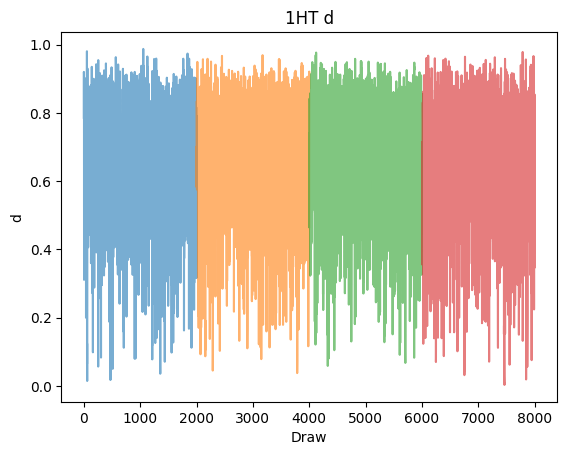

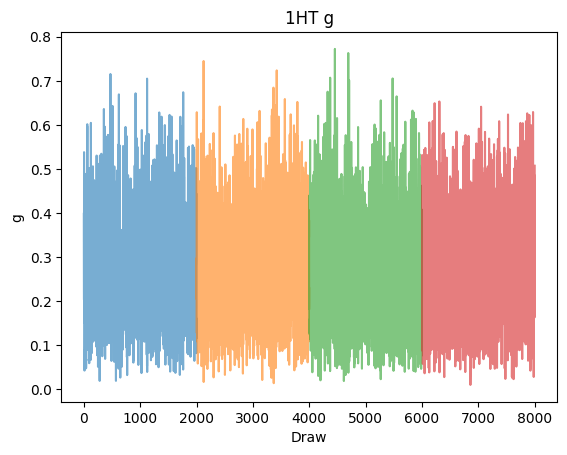

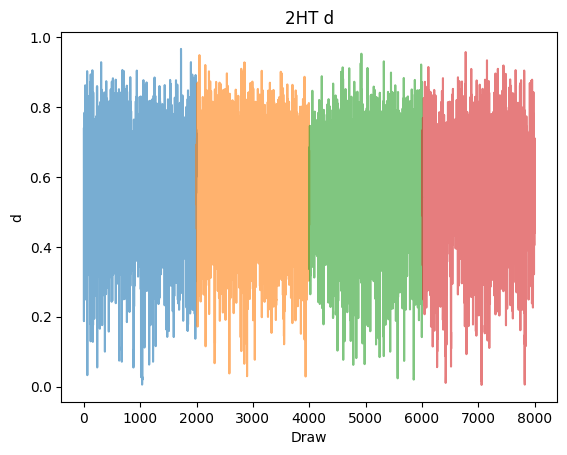

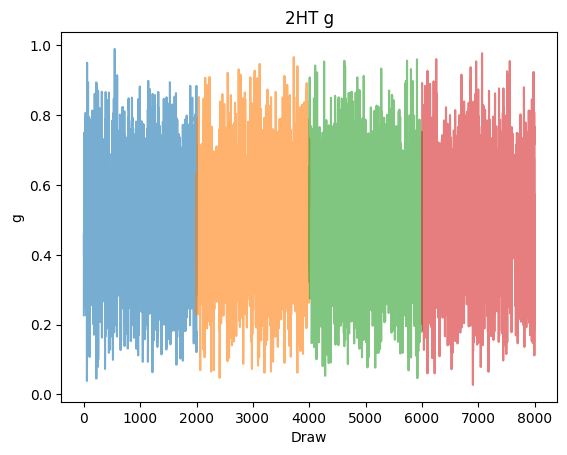

In [10]:
def traceplot(fit, param, title):
    draws = fit.draws_pd()
    for chain in draws["chain__"].unique():
        sub = draws[draws["chain__"] == chain]
        plt.plot(sub["draw__"], sub[param], alpha=0.6)

    plt.title(title)
    plt.xlabel("Draw")
    plt.ylabel(param)
    plt.show()

traceplot(fit_1ht, "d", "1HT d")
traceplot(fit_1ht, "g", "1HT g")

traceplot(fit_2ht, "d", "2HT d")
traceplot(fit_2ht, "g", "2HT g")

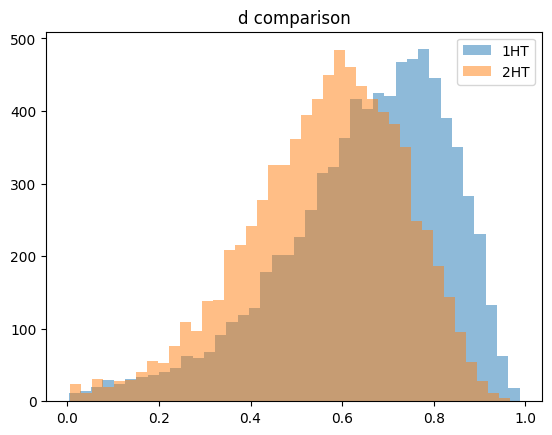

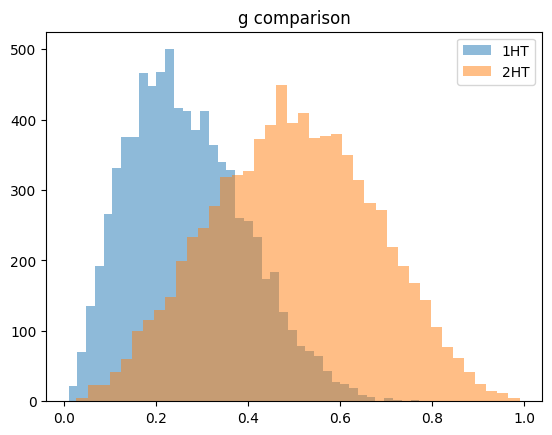

In [11]:
d1 = fit_1ht.stan_variable("d")
g1 = fit_1ht.stan_variable("g")

d2 = fit_2ht.stan_variable("d")
g2 = fit_2ht.stan_variable("g")

plt.hist(d1, bins=40, alpha=0.5, label="1HT")
plt.hist(d2, bins=40, alpha=0.5, label="2HT")
plt.title("d comparison")
plt.legend()
plt.show()

plt.hist(g1, bins=40, alpha=0.5, label="1HT")
plt.hist(g2, bins=40, alpha=0.5, label="2HT")
plt.title("g comparison")
plt.legend()
plt.show()